# OLS & (Imperfect) Multicollinearity: Monte Carlo Method
This notebook examines how multicollinearity impacts OLS estimators in two parts.

Part 1: Generates a synthetic dataset using Monte Carlo simulations.

Part 2: Analyses how varying collinearity levels affect estimator means and standard errors.

## Part 1 - Generating the Data

Creation of the DataFrame to study the effects of (imperfect) multicollinearity on the OLS estimators.

The true population function as a DGP is assumed to be $Y_i=\beta_0+\beta X_{1i} +\beta X_{2i}$ with the true known parameters $\beta_0=2$, $\beta_1=3$ and $\beta_2=0.5$.

Based on this DGP, the Python code below uses Monte Carlo simulation to gerenerate 10,000 OLS estimators $\hat{\beta_0}$, $\hat{\beta_1}$, $\hat{\beta_2}$ for different levels of correlation between independent variables $X_1$ and $X_2$. Correlation levels are: $\rho=0$, $\rho=0.25$, $\rho=0.5$, $\rho=0.75$, $\rho=0.9$ and $\rho=0.99$. Sample size in each simulation run is $N=50$.

Final results are stored in a DataFrame and exported as csv and parquet files.

In [82]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# --- Simulation Parameters ---
N_OBS = 50         # Sample size per regression
N_SIMS = 10000      # Number of Monte Carlo iterations
BETA_0 = 2.0        # Intercept
BETA_1 = 3.0        # True coefficient for X1
BETA_2 = 0.5        # True coefficient for X2
RHO_VALUES = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]  # Correlation levels to test

def run_monte_carlo(rho, n_obs=N_OBS, n_sims=N_SIMS):
    b0_estimates = []
    b1_estimates = []
    b2_estimates = []

    for _ in range(n_sims):
        # 1. Generate correlated predictors X1 and X2
        cov_matrix = [[1, rho], [rho, 1]]
        X1, X2 = np.random.multivariate_normal([0, 0], cov_matrix, n_obs).T

        # 2. Generate response variable Y with normally distributed noise
        epsilon = np.random.normal(0, 3, n_obs)
        Y = BETA_0 + BETA_1 * X1 + BETA_2 * X2 + epsilon

        # 3. Fit OLS Regression
        X_design = np.column_stack([X1, X2])
        X_design = sm.add_constant(X_design)
        model = sm.OLS(Y, X_design).fit()

        # 4. Store estimated coefficients
        b0_estimates.append(model.params[0])
        b1_estimates.append(model.params[1])
        b2_estimates.append(model.params[2])

    return b0_estimates, b1_estimates, b2_estimates

# --- Store results in single DataFrames ---
my_dict={}
for index, rho in enumerate(RHO_VALUES):
    b0_hat, b1_hat, b2_hat = run_monte_carlo(rho)

    my_dict[index] = pd.DataFrame({
    'beta_0': b0_hat,
    'beta_1': b1_hat,
    'beta_2': b2_hat,
    'rho': rho
    })

# --- Combining all single DataFrames & exporting to files---
df_big=pd.concat([x for x in my_dict.values()],ignore_index=True)
df_big.to_csv("OLS_Multicollinearity.csv", index=False)
df_big.to_parquet("OLS_Multicollinearity.parquet")


# --- Generating one sample ---
rho=0.95
n_obs=50

cov_matrix = [[1, rho], [rho, 1]]
X1, X2 = np.random.multivariate_normal([0, 0], cov_matrix, n_obs).T

epsilon = np.random.normal(0, 1, n_obs)
Y = BETA_0 + BETA_1 * X1 + BETA_2 * X2 + epsilon

df_obs = pd.DataFrame({'X1': X1, 'X2': X2, 'Y': Y})
df_obs.to_csv("OLS_Multicollinearity_Sample.csv", index=False)
df_obs.to_parquet("OLS_Multicollinearity_Sample.parquet")


## Part 2 - Using the Data


### Illustrating One Sample with High Correlation ($\rho=0.95$)


Correlation Matrix (Pearson):
          X1        X2         Y
X1  1.000000  0.949037  0.969994
X2  0.949037  1.000000  0.914907
Y   0.969994  0.914907  1.000000

Variance Inflation Factors:
feature       VIF
     X1 10.067567
     X2 10.067567


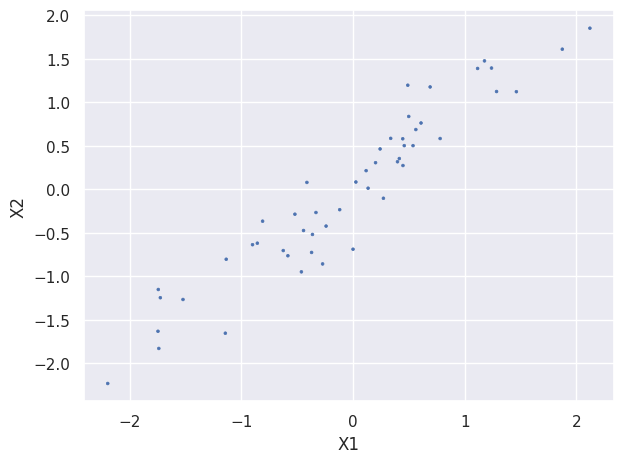

In [53]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn.objects as so
import statsmodels.api as sm


# Load sample data

df_sample=pd.read_parquet("https://raw.githubusercontent.com/MichaelWegener/SDP-302---Fall-2026/refs/heads/main/data/OLS_Multicollinearity_Sample.parquet")

#1 Calculate and print the correlation matrix
corr_matrix = df_sample.corr(method='pearson')
print("\nCorrelation Matrix (Pearson):")
print(corr_matrix)

# 1. Selecting x columns
X=df_sample[['X1', 'X2']]

# 2. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factors:")
print(vif_data.to_string(index=False))

# Create a basic scatter plot
(
    so.Plot(df_sample, x="X1", y="X2")
    .add(so.Dot(pointsize=2))
    .show()
)

In [54]:
df_sample = sm.add_constant(df_sample)
X_df = df_sample[['const', "X1", "X2"]]
Y=df_sample["Y"]
model = sm.OLS(Y, X_df)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     376.2
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           1.20e-29
Time:                        16:03:16   Log-Likelihood:                -66.136
No. Observations:                  50   AIC:                             138.3
Df Residuals:                      47   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0933      0.133     15.724      0.0

### Comparing the  Mean and SD of the Estimators for Different Levels of Correlation

In [84]:
# Import the data
df=pd.read_parquet("https://raw.githubusercontent.com/MichaelWegener/SDP-302---Fall-2026/refs/heads/main/data/OLS_Multicollinearity.parquet")

# Recalling the true values
BETA_0 = 2.0        # Intercept
BETA_1 = 3.0        # True coefficient for X1
BETA_2 = 0.5        # True coefficient for X2
RHO_VALUES = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]  # Correlation levels to test

results = []
# Iterating over all correlation values
for rho in RHO_VALUES:

    # Filter the DataFrame for the exact correlation values
    filtered_df = df[df['rho'] == rho]
    b1_hat=filtered_df["beta_1"]
    b2_hat=filtered_df["beta_2"]

    # Calculate the mean and the sd of the estimators and append the results to a list
    results.append({
        "Correlation (ρ)": rho,
        "Mean β1 (True = 3.0)": round(np.mean(b1_hat), 3),
        "Std Dev (β1)": round(np.std(b1_hat), 3),
        "Mean β2 (True = 0.5)": round(np.mean(b2_hat), 3),
        "Std Dev (β2)": round(np.std(b2_hat), 3),
    })

# Put the final list in a DataFrame and print it
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))



 Correlation (ρ)  Mean β1 (True = 3.0)  Std Dev (β1)  Mean β2 (True = 0.5)  Std Dev (β2)
            0.00                 3.001         0.442                 0.495         0.439
            0.25                 2.996         0.459                 0.499         0.457
            0.50                 3.013         0.507                 0.494         0.507
            0.75                 3.010         0.668                 0.502         0.661
            0.90                 2.982         1.021                 0.517         1.024
            0.95                 3.016         1.414                 0.477         1.411
            0.99                 2.985         3.154                 0.516         3.157


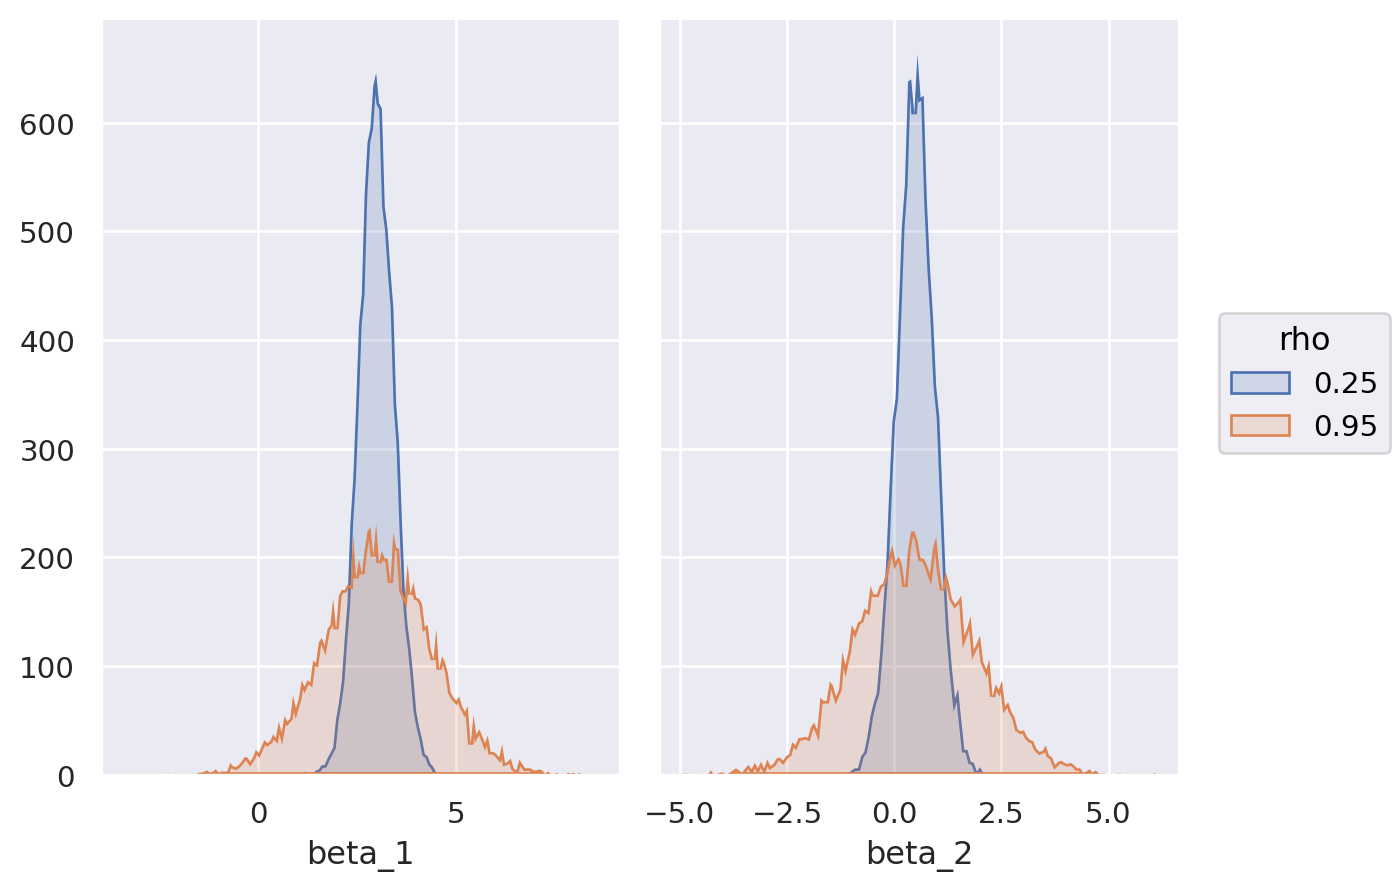

In [123]:
df['rho'] = df['rho'].astype("string")
allowed_roles = ["0.25", "0.95"]
filtered_df = df[df['rho'].isin(allowed_roles)]
(
    so.Plot(filtered_df)
    .pair(x=["beta_1", "beta_2"])
    .add(so.Area(), so.Hist(), color="rho")
)